In [2]:
import ast
import pandas as pd
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date']= pd.to_datetime(df.job_posted_date)
import matplotlib.pyplot as plt

df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)


In [4]:
df_exploded = df.explode('job_skills')

In [10]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

type (skills_count)

pandas.Series

In [22]:
df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count = df_skills_count.sort_values(by ='skill_count', ascending=True)

df_skills_count

,job_title_short,job_skills,skill_count
45,Business Analyst,digitalocean,1
21,Business Analyst,capacitor,1
24,Business Analyst,chainer,1
29,Business Analyst,codecommit,1
1175,Machine Learning Engineer,clickup,1
...,...,...,...
1101,Data Scientist,sql,78982
625,Data Analyst,sql,92428
830,Data Engineer,python,108022
865,Data Engineer,sql,113130


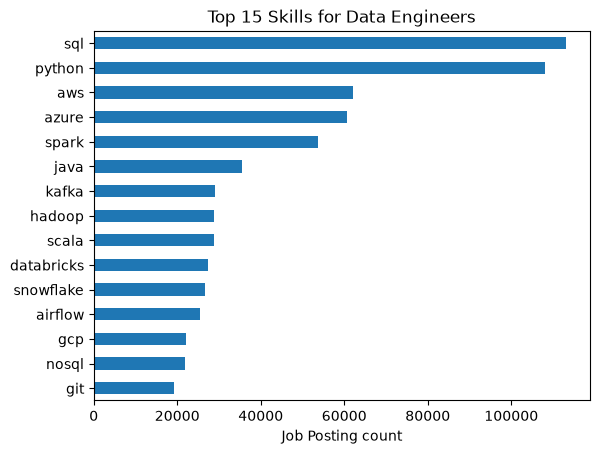

In [28]:
job_title= 'Data Engineer'
top_skills = 15

df.skill_final = df_skills_count[df_skills_count [ 'job_title_short'] == job_title].tail(top_skills)

df.skill_final.plot(kind = 'barh', x = 'job_skills', y='skill_count')
(plt.gca().invert_yaxis)
plt.title (f'Top {top_skills} Skills for {job_title}s')
plt.xlabel('Job Posting count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()